<a href="https://colab.research.google.com/github/LielUziahu/MDPI_S_Pistillata_Bet-Hedging/blob/main/Spat_Physiology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Styling & Setup
Imports the required data science packages and sets the visual fingerprint (fonts, colors, and line weights) so the final plot perfectly matches previous  figures.

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 20,      # Global title padding
    "axes.labelsize": 12,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "svg.fonttype": "none" # Protects text vectors for journal export
})
sns.set_theme(style="white", font="serif")

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

sub_condition_plot_order = [
    'Ambient \n(23°C, pH 8.2, 10m)',
    '27°C',
    '32°C',
    'pH 7.8',
    'pH 7.6',
    '50m',
    'Dark',
]

global_fig_size = (10, 6)
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6
# Centralized Asterisk Settings - UPDATED to smaller size
global_asterisk_size = 12
global_asterisk_weight = 'bold'

# Added for cleaner look
global_y_nbins = 3

print(f"Global styling initialized. Asterisk size reduced to {global_asterisk_size}.")

Global styling initialized. Asterisk size reduced to 12.


# Settlment


## Block 1: Data Loading, Cleaning, and Phenotype Filtering.
In this block, we standardize the column names and morph labels from your four different CSV files, remove the "Partial Fluorescent" (PF) data as requested by your PI, and merge them into a single "Master" dataset for analysis.

In [20]:
import pandas as pd
import numpy as np

# --- HELPER FUNCTION ---
def clean_morph(val):
    """Standardizes morph labels and handles typos/extra spaces."""
    val = str(val).strip().lower()
    if 'high' in val or 'hf' == val:
        return 'HF'
    if 'no' in val or 'nf' == val:
        return 'NF'
    if 'partial' in val or 'pf' == val:
        return 'PF'
    return None

# ==========================================
# BLOCK 1: LOADING & STANDARDIZING DATA
# ==========================================

# 1. Load Ambient (Control)
df_amb = pd.read_csv("Settlment_Ambient.csv")
df_amb['morph'] = df_amb['Varient'].apply(clean_morph)
df_amb = df_amb.rename(columns={'setteled %': 'settlement'})[['morph', 'settlement']]
df_amb['Treatment'] = 'Ambient'

# 2. Load Depth (Light) - Filtering for 50m and Dark
df_depth = pd.read_csv("Settlement_Depth.csv")
df_depth['morph'] = df_depth['fluorescense level'].apply(clean_morph)
df_depth['settlement'] = pd.to_numeric(df_depth['setteled %'], errors='coerce')
# We exclude '10m' here because it is covered by the 'Ambient' control
df_depth = df_depth[df_depth['Light'].astype(str).str.upper().isin(['50M', 'DARK'])].copy()
df_depth['Treatment'] = df_depth['Light'].str.capitalize()

# 3. Load pH Stress
df_ph = pd.read_csv("Settlement_pH.csv")
df_ph['morph'] = df_ph['fluorescense level'].apply(clean_morph)
df_ph['settlement'] = pd.to_numeric(df_ph['setteled %'], errors='coerce')
df_ph = df_ph[df_ph['pH'].astype(str).isin(['7.8', '7.6'])].copy()
df_ph['Treatment'] = 'pH ' + df_ph['pH'].astype(str)

# 4. Load Thermal Stress
df_temp = pd.read_csv("Settlement_Temp.csv")
df_temp['morph'] = df_temp['fluorescense level'].apply(clean_morph)
df_temp['settlement'] = pd.to_numeric(df_temp['setteled %'], errors='coerce')
df_temp = df_temp[df_temp['Temp'].astype(float).isin([27, 32])].copy()
df_temp['Treatment'] = df_temp['Temp'].astype(float).astype(int).astype(str) + '°C'

# 5. Combine all into Master DataFrame and REMOVE 'PF'
master_df = pd.concat([
    df_amb,
    df_depth[['morph', 'settlement', 'Treatment']],
    df_ph[['morph', 'settlement', 'Treatment']],
    df_temp[['morph', 'settlement', 'Treatment']]
])

# Final Cleaning: Drop rows with missing values and remove the PF morph
master_df = master_df.dropna(subset=['morph', 'settlement'])
master_df = master_df[master_df['morph'] != 'PF'].copy()

print(f"Block 1 Complete.")
print(f"Total observations: {len(master_df)}")
print(f"Morphs remaining: {master_df['morph'].unique()}")
print(f"Treatments loaded: {master_df['Treatment'].unique().tolist()}")
print(master_df.head())

Block 1 Complete.
Total observations: 126
Morphs remaining: ['NF' 'HF']
Treatments loaded: ['Ambient', '50m', 'Dark', 'pH 7.8', 'pH 7.6', '27°C', '32°C']
  morph  settlement Treatment
0    NF        15.0   Ambient
1    NF        70.0   Ambient
2    NF        30.0   Ambient
3    NF        20.0   Ambient
4    NF        70.0   Ambient


## Block 2: Outlier Removal via 1.5*IQR.
This block ensures that technical "noise" or extreme values don't skew your final results. We perform this calculation separately for each group (e.g., HF in Ambient vs. NF in Ambient) to account for the natural variance within each phenotype.

In [21]:
# ==========================================
# BLOCK 2: OUTLIER REMOVAL (1.5 * IQR)
# ==========================================

def remove_outliers_iqr(df, group_cols, target_col):
    """
    Filters out rows that are outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    calculated per specific experimental group.
    """
    def filter_group(group):
        q1 = group[target_col].quantile(0.25)
        q3 = group[target_col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Return only the values within the bounds
        return group[(group[target_col] >= lower_bound) & (group[target_col] <= upper_bound)]

    return df.groupby(group_cols, group_keys=False).apply(filter_group)

# Count before removal for reporting
count_before = len(master_df)

# Apply outlier removal per Morph and Treatment
master_df_clean = remove_outliers_iqr(master_df, ['morph', 'Treatment'], 'settlement')

# Calculate how many were removed
count_after = len(master_df_clean)
removed_count = count_before - count_after

print(f"Block 2 Complete.")
print(f"Outliers removed: {removed_count}")
print(f"Remaining data points for analysis: {count_after}")

# Summary of N per group after cleaning
print("\nSample size per group (N):")
print(master_df_clean.groupby(['Treatment', 'morph']).size().unstack(fill_value=0))

Block 2 Complete.
Outliers removed: 4
Remaining data points for analysis: 122

Sample size per group (N):
morph      HF  NF
Treatment        
27°C        9   7
32°C       10   7
50m         5   6
Ambient    25  21
Dark        6   6
pH 7.6      5   5
pH 7.8      5   5


/tmp/ipykernel_1349/262408116.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, group_keys=False).apply(filter_group)


## Block 3: Normality Check (Shapiro-Wilk Test).
This block is essential for determining whether your data follows a normal distribution. In scientific publishing, this step dictates which statistical test is appropriate: a Parametric test (like a T-test or ANOVA) if the data is normal, or a Non-Parametric test (like Mann-Whitney U or Kruskal-Wallis) if it is not.

In [22]:
from scipy import stats

# ==========================================
# BLOCK 3: NORMALITY CHECK (SHAPIRO-WILK)
# ==========================================

print("--- BLOCK 3: RUNNING NORMALITY CHECKS ---")

normality_results = []

# Iterate through every experimental group to test for normality
for (treat, morph), group in master_df_clean.groupby(['Treatment', 'morph']):
    data = group['settlement']

    # Shapiro-Wilk requires at least 3 samples
    if len(data) >= 3:
        shapiro_stat, p_value = stats.shapiro(data)
        is_normal = p_value > 0.05  # Standard alpha threshold
    else:
        # If N < 3, we cannot reliably test normality
        shapiro_stat, p_value = np.nan, np.nan
        is_normal = False

    normality_results.append({
        'Treatment': treat,
        'Morph': morph,
        'N': len(data),
        'W_Statistic': shapiro_stat,
        'p_value': p_value,
        'Normal_Distribution': is_normal
    })

# Convert results to a DataFrame for easy viewing
normality_df = pd.DataFrame(normality_results)

# Display the report
print("\n[NORMALITY REPORT]")
print(normality_df.to_string(index=False))

# Calculate global status
failed_groups = normality_df[normality_df['Normal_Distribution'] == False]
if failed_groups.empty:
    print("\nCONCLUSION: All groups are normally distributed. Use PARAMETRIC tests (T-test/ANOVA).")
else:
    print(f"\nCONCLUSION: {len(failed_groups)} groups failed the normality test.")
    print("ACTION: The pipeline will automatically use NON-PARAMETRIC tests (Mann-Whitney U) for these conditions.")

--- BLOCK 3: RUNNING NORMALITY CHECKS ---

[NORMALITY REPORT]
Treatment Morph  N  W_Statistic  p_value  Normal_Distribution
     27°C    HF  9     0.938487 0.566067                 True
     27°C    NF  7     0.937287 0.614417                 True
     32°C    HF 10     0.823614 0.028023                False
     32°C    NF  7     0.899899 0.330371                 True
      50m    HF  5     0.881038 0.314040                 True
      50m    NF  6     0.931672 0.593073                 True
  Ambient    HF 25     0.939298 0.142605                 True
  Ambient    NF 21     0.882864 0.016513                False
     Dark    HF  6     0.913352 0.458810                 True
     Dark    NF  6     0.684207 0.004196                False
   pH 7.6    HF  5     0.684029 0.006470                False
   pH 7.6    NF  5     0.766717 0.042199                False
   pH 7.8    HF  5     0.978716 0.927636                 True
   pH 7.8    NF  5     0.952960 0.758312                 True

CONCLUS

## Block 4: Automated Statistical Analysis.
This block uses the results from the normality check in Block 3 to decide which test to perform for each environmental condition. It compares the High Fluorescent (HF) and Non-Fluorescent (NF) morphs directly to see where the phenotypic advantages lie.

In [23]:
# ==========================================
# BLOCK 4: AUTOMATED STATISTICAL ANALYSIS
# ==========================================

print("--- BLOCK 4: PERFORMING COMPARATIVE STATS ---")

stats_results = []

# Analyze each Treatment condition separately
for treat in master_df_clean['Treatment'].unique():
    # Subset data for this specific stressor
    subset = master_df_clean[master_df_clean['Treatment'] == treat]
    hf_data = subset[subset['morph'] == 'HF']['settlement']
    nf_data = subset[subset['morph'] == 'NF']['settlement']

    # 1. Determine which test to use based on Normality results for THIS treatment
    # We check if BOTH morphs in this treatment passed the normality test (p > 0.05)
    subset_normality = normality_df[normality_df['Treatment'] == treat]
    is_normal = subset_normality['Normal_Distribution'].all()

    if is_normal:
        # PARAMETRIC: Independent T-test
        stat, p_val = stats.ttest_ind(hf_data, nf_data)
        test_name = "Independent T-test"
    else:
        # NON-PARAMETRIC: Mann-Whitney U test
        stat, p_val = stats.mannwhitneyu(hf_data, nf_data)
        test_name = "Mann-Whitney U"

    # 2. Log the results
    stats_results.append({
        'Condition': treat,
        'HF_Mean': hf_data.mean(),
        'NF_Mean': nf_data.mean(),
        'Difference': hf_data.mean() - nf_data.mean(),
        'p_value': p_val,
        'Test_Used': test_name,
        'Significant': p_val < 0.05
    })

# Convert to DataFrame for the final poster report
results_df = pd.DataFrame(stats_results)

# Display the Final Statistical Summary
print("\n[FINAL SETTLEMENT ANALYSIS SUMMARY]")
print(results_df[['Condition', 'HF_Mean', 'NF_Mean', 'p_value', 'Significant', 'Test_Used']].to_string(index=False))

# Save this summary to a CSV for your records
results_df.to_csv("Settlement_Statistical_Results.csv", index=False)

--- BLOCK 4: PERFORMING COMPARATIVE STATS ---

[FINAL SETTLEMENT ANALYSIS SUMMARY]
Condition   HF_Mean   NF_Mean  p_value  Significant          Test_Used
     27°C 36.666667 35.714286 0.947607        False Independent T-test
     32°C 22.000000 18.571429 1.000000        False     Mann-Whitney U
      50m 68.000000 43.333333 0.161353        False Independent T-test
  Ambient 50.800000 35.238095 0.012169         True     Mann-Whitney U
     Dark 28.333333 35.000000 0.459148        False     Mann-Whitney U
   pH 7.6 42.000000 20.000000 0.076416        False     Mann-Whitney U
   pH 7.8 48.000000 26.000000 0.110175        False Independent T-test


## Block 5: High-Impact Visualization
This block generates a publication-quality figure It combines the raw data points (to show variance) with boxplots (to show medians) and adds significance markers based on the results from Block 4.

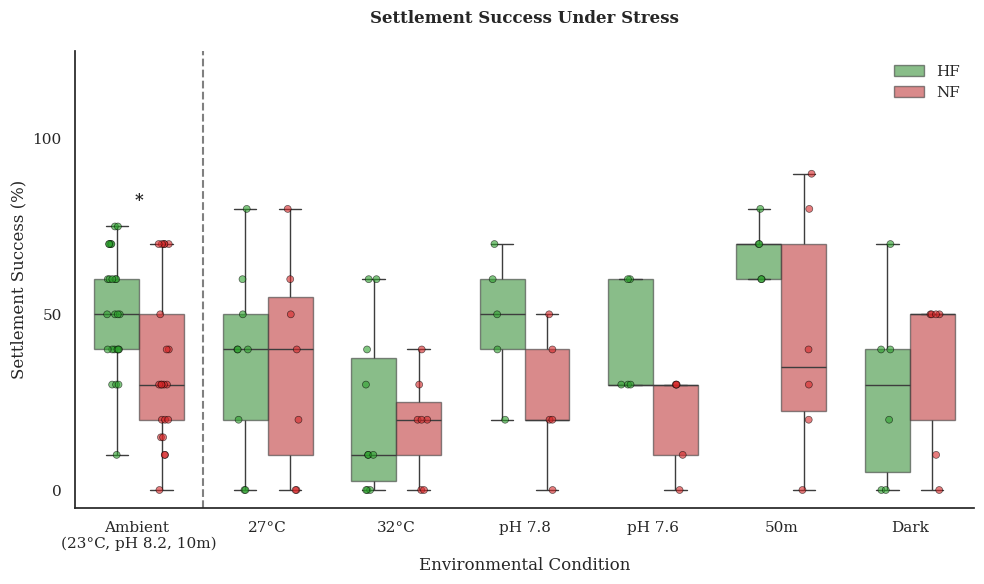

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==========================================
# BLOCK 5: HIGH-IMPACT VISUALIZATION (SETTLEMENT)
# ==========================================

master_df_clean['Treatment'] = master_df_clean['Treatment'].replace('Ambient', 'Ambient \n(23°C, pH 8.2, 10m)')

fig, ax = plt.subplots(figsize=global_fig_size)

sns.boxplot(data=master_df_clean, x='Treatment', y='settlement', hue='morph', order=sub_condition_plot_order, palette=variant_colors, ax=ax, width=0.7, boxprops=dict(alpha=global_alpha), showfliers=False)
sns.stripplot(data=master_df_clean, x='Treatment', y='settlement', hue='morph', order=sub_condition_plot_order, palette=variant_colors, ax=ax, dodge=True, size=global_marker_size, alpha=global_alpha, jitter=global_jitter, edgecolor='black', linewidth=0.5, legend=False)

# Updated Significance Logic: Tiered system
for idx, row in results_df.iterrows():
    p_val = row['p_value']
    if p_val < 0.05:
        sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
        condition = row['Condition']
        plot_label = 'Ambient \n(23°C, pH 8.2, 10m)' if condition == 'Ambient' else condition
        if plot_label in sub_condition_plot_order:
            x_pos = sub_condition_plot_order.index(plot_label)
            max_y = master_df_clean[master_df_clean['Treatment'] == plot_label]['settlement'].max()
            ax.text(x_pos, max_y + 5, sig_text, ha='center', va='bottom', fontsize=global_asterisk_size, fontweight=global_asterisk_weight)

ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5)
ax.set_title("Settlement Success Under Stress")
ax.set_xlabel("Environmental Condition")
ax.set_ylabel("Settlement Success (%)")
ax.set_ylim(-5, 125)

# Aesthetic Legend refinement
ax.legend(frameon=False)

if 'global_y_nbins' in globals():
    ax.yaxis.set_major_locator(plt.MaxNLocator(global_y_nbins))

sns.despine()
plt.tight_layout()
plt.savefig("Master_Settlement_Poster_Plot.png", dpi=600, bbox_inches='tight')
plt.show()

# Dark Respiration Rate

## Block 1: Loading & Standardization (Respiration)
This block pulls the oxygen consumption rates from all four files, cleans the morph labels (HF vs NF), and maps the experimental treatments.

In [14]:
import pandas as pd
import numpy as np

# --- HELPER FUNCTION ---
def clean_morph(val):
    val = str(val).strip().upper()
    if 'HF' in val or 'HIGH' in val: return 'HF'
    if 'NF' in val or 'NO' in val: return 'NF'
    return None

# 1. Load Files (Corrected filenames based on content)
df_amb = pd.read_csv('Ambiant_Spat_Resp.csv')
df_ph = pd.read_csv('pH_Spat_Resp.csv')
df_temp = pd.read_csv('Temp_Spat_Resp.csv')
df_light = pd.read_csv('Light_Spat_Resp.csv')

# 2. Map Treatments and Clean Morphs (Updated to use correct morph/color column)
# Ambient
df_amb['morph_clean'] = df_amb['Morph'].apply(clean_morph) # Corrected column name to 'Morph'
df_amb['Treatment'] = 'Ambient \n(23°C, pH 8.2, 10m)'

# pH
df_ph['morph_clean'] = df_ph['color'].apply(clean_morph) # Corrected column name to 'color'
df_ph = df_ph[df_ph['pH'].isin([7.6, 7.8])].copy()
df_ph['Treatment'] = df_ph['pH'].apply(lambda x: f"pH {x}")

# Temp
df_temp['morph_clean'] = df_temp['color'].apply(clean_morph) # Corrected column name to 'color'
df_temp = df_temp[df_temp['temp'].isin([27, 32])].copy()
df_temp['Treatment'] = df_temp['temp'].apply(lambda x: f"{x}°C")

# Light
df_light['morph_clean'] = df_light['color'].apply(clean_morph) # Corrected column name to 'color'
df_light = df_light[df_light['LightDepth'].str.lower().isin(['50m', 'dark'])].copy()
df_light['Treatment'] = df_light['LightDepth'].str.capitalize()

# 3. Combine into Master Respiration DataFrame
cols_to_take = ['SampleCode', 'morph_clean', 'OxyRate nmol/mm2/min', 'Treatment']
master_respiration = pd.concat([df_amb[cols_to_take], df_ph[cols_to_take], df_temp[cols_to_take], df_light[cols_to_take]])

# Cleanup column names
master_respiration = master_respiration.rename(columns={'morph_clean': 'morph', 'OxyRate nmol/mm2/min': 'oxy_rate'})

# Drop PF and missing values
master_respiration = master_respiration[master_respiration['morph'].isin(['HF', 'NF'])].dropna()

print("Block 1 Complete: Master Respiration Data Merged.")

Block 1 Complete: Master Respiration Data Merged.


## Block 2: Outlier Removal & "Removed Samples" List

This block will not only clean the data using the $1.5 \times \text{IQR}$ rule but will also print the specific IDs and treatments of the samples that were removed.

In [15]:
# ==========================================
# BLOCK 2: OUTLIER REMOVAL & LOGGING
# ==========================================

master_respiration['is_outlier'] = False

for names, group in master_respiration.groupby(['morph', 'Treatment']):
    q1 = group['oxy_rate'].quantile(0.25)
    q3 = group['oxy_rate'].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    # Identify indices of outliers for this group
    indices = group[(group['oxy_rate'] < lower) | (group['oxy_rate'] > upper)].index
    master_respiration.loc[indices, 'is_outlier'] = True

# 1. Generate the list of samples that got removed
removed_respiration = master_respiration[master_respiration['is_outlier'] == True][['SampleCode', 'morph', 'Treatment', 'oxy_rate']]

# 2. Create the clean dataset for analysis
respiration_clean = master_respiration[master_respiration['is_outlier'] == False].copy()

# 3. Remove negative results
respiration_clean = respiration_clean[respiration_clean['oxy_rate'] >= 0].copy()

print(f"Block 2 Complete. {len(removed_respiration)} outliers removed.")
print(f"Final N for analysis: {len(respiration_clean)}")

Block 2 Complete. 20 outliers removed.
Final N for analysis: 324


In [16]:
from scipy import stats

# ==========================================
# BLOCK 3: NORMALITY CHECK (RESPIRATION)
# ==========================================

print("--- BLOCK 3: RUNNING NORMALITY CHECKS ---")

oxy_normality_results = []

for (treat, morph), group in respiration_clean.groupby(['Treatment', 'morph']):
    data = group['oxy_rate']
    if len(data) >= 3:
        shapiro_stat, p_value = stats.shapiro(data)
        is_normal = p_value > 0.05
    else:
        shapiro_stat, p_value = np.nan, 0.0
        is_normal = False

    oxy_normality_results.append({
        'Treatment': treat,
        'Morph': morph,
        'N': len(data),
        'W_Statistic': round(shapiro_stat, 4) if not np.isnan(shapiro_stat) else np.nan,
        'p_value': round(p_value, 4) if not np.isnan(p_value) else np.nan,
        'Normal_Distribution': is_normal
    })

oxy_normality_df = pd.DataFrame(oxy_normality_results)
print("\n[RESPIRATION NORMALITY REPORT]")
print(oxy_normality_df.to_string(index=False))

--- BLOCK 3: RUNNING NORMALITY CHECKS ---

[RESPIRATION NORMALITY REPORT]
                    Treatment Morph  N  W_Statistic  p_value  Normal_Distribution
                         27°C    HF 28       0.9157   0.0272                False
                         27°C    NF 25       0.9006   0.0189                False
                         32°C    HF  9       0.8799   0.1568                 True
                         32°C    NF  7       0.9187   0.4595                 True
                          50m    HF 18       0.9410   0.3012                 True
                          50m    NF 10       0.8702   0.1004                 True
Ambient \n(23°C, pH 8.2, 10m)    HF 84       0.9722   0.0660                 True
Ambient \n(23°C, pH 8.2, 10m)    NF 45       0.9108   0.0021                False
                         Dark    HF 10       0.8957   0.1965                 True
                         Dark    NF  8       0.8803   0.1897                 True
                       p

## Block 4: Automated Statistical Analysis (Respiration).
This block performs the direct metabolic comparison between High-Fluorescent (HF) and Non-Fluorescent (NF) recruits. By using the distribution data from Block 3, it ensures that your $p$-values are calculated using the most conservative and accurate mathematical approach.

In [17]:
# ==========================================
# BLOCK 4: AUTOMATED STATISTICAL ANALYSIS
# ==========================================

print("--- BLOCK 4: PERFORMING COMPARATIVE METABOLIC STATS ---")

oxy_stats_results = []

for treat in respiration_clean['Treatment'].unique():
    subset = respiration_clean[respiration_clean['Treatment'] == treat]
    hf_data = subset[subset['morph'] == 'HF']['oxy_rate']
    nf_data = subset[subset['morph'] == 'NF']['oxy_rate']

    subset_normality = oxy_normality_df[oxy_normality_df['Treatment'] == treat]
    is_normal = subset_normality['Normal_Distribution'].all()

    if len(hf_data) >= 2 and len(nf_data) >= 2:
        if is_normal:
            stat, p_val = stats.ttest_ind(hf_data, nf_data)
            test_name = "Independent T-test"
        else:
            stat, p_val = stats.mannwhitneyu(hf_data, nf_data)
            test_name = "Mann-Whitney U"
    else:
        p_val, test_name = np.nan, "Insufficient N"

    oxy_stats_results.append({
        'Condition': treat,
        'HF_Mean_Rate': round(hf_data.mean(), 4),
        'NF_Mean_Rate': round(nf_data.mean(), 4),
        'p_value': round(p_val, 4) if not np.isnan(p_val) else np.nan,
        'Test_Used': test_name,
        'Significant': p_val < 0.05 if not np.isnan(p_val) else False
    })

oxy_results_df = pd.DataFrame(oxy_stats_results)
print("\n[RESPIRATION COMPARATIVE ANALYSIS SUMMARY]")
print(oxy_results_df[['Condition', 'HF_Mean_Rate', 'NF_Mean_Rate', 'p_value', 'Significant', 'Test_Used']].to_string(index=False))

significant_results = oxy_results_df[oxy_results_df['Significant'] == True]

print("\n--- STATISTICALLY SIGNIFICANT RESPIRATION RESULTS ---")
if significant_results.empty:
    print("No statistically significant differences were found.")
else:
    print(significant_results[['Condition', 'HF_Mean_Rate', 'NF_Mean_Rate', 'p_value', 'Test_Used']].to_string(index=False))

--- BLOCK 4: PERFORMING COMPARATIVE METABOLIC STATS ---

[RESPIRATION COMPARATIVE ANALYSIS SUMMARY]
                    Condition  HF_Mean_Rate  NF_Mean_Rate  p_value  Significant          Test_Used
Ambient \n(23°C, pH 8.2, 10m)        0.7710        0.6869   0.2366        False     Mann-Whitney U
                       pH 7.6        1.3122        1.0781   0.1336        False Independent T-test
                       pH 7.8        0.5525        1.0250   0.0006         True Independent T-test
                         27°C        0.2752        0.2159   0.2891        False     Mann-Whitney U
                         32°C        0.1927        0.0467   0.0283         True Independent T-test
                          50m        0.6417        0.2834   0.0420         True Independent T-test
                         Dark        0.4786        0.4242   0.7147        False Independent T-test

--- STATISTICALLY SIGNIFICANT RESPIRATION RESULTS ---
Condition  HF_Mean_Rate  NF_Mean_Rate  p_value       

## Block 5: High-Impact Visualization (Respiration-Only).
This plot is designed to be the "physiological heart" of your poster. It visualizes the metabolic cost of living for each phenotype across the environmental gradient. By showing the raw data points over the boxplots, you provide full transparency regarding the variance in your micro-respirometry measurements.

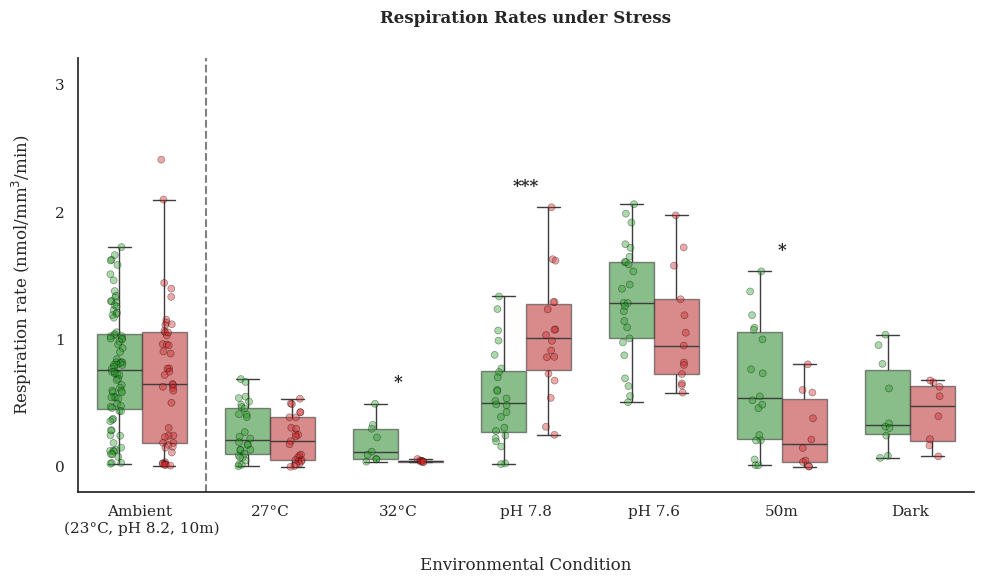

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ==========================================
# BLOCK 5: MASTER RESPIRATION PLOT
# ==========================================

fig, ax = plt.subplots(figsize=global_fig_size)

# Note: strip plot legend is disabled to prevent jitter points from appearing in the legend
sns.boxplot(data=respiration_clean, x='Treatment', y='oxy_rate', hue='morph', hue_order=['HF', 'NF'], order=sub_condition_plot_order, palette=variant_colors, ax=ax, width=0.7, boxprops=dict(alpha=global_alpha), showfliers=False)
sns.stripplot(data=respiration_clean, x='Treatment', y='oxy_rate', hue='morph', hue_order=['HF', 'NF'], order=sub_condition_plot_order, palette=variant_colors, ax=ax, dodge=True, size=global_marker_size, alpha=0.4, jitter=global_jitter, edgecolor='black', linewidth=0.5, legend=False)

ax.set_title("Respiration Rates under Stress", fontweight='bold', pad=25)
ax.set_xlabel("Environmental Condition", labelpad=15)
ax.set_ylabel(r"Respiration rate (nmol/mm$^3$/min)", labelpad=15)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5)
ax.set_ylim(respiration_clean['oxy_rate'].min() - 0.2, respiration_clean['oxy_rate'].max() + 0.8)

# Updated Significance Logic: Tiered system
if 'oxy_results_df' in globals():
    for idx, row in oxy_results_df.iterrows():
        p_val = row['p_value']
        if p_val < 0.05:
            sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
            condition = row['Condition']
            if condition in sub_condition_plot_order:
                x_pos = sub_condition_plot_order.index(condition)
                max_y = respiration_clean[respiration_clean['Treatment'] == condition]['oxy_rate'].max()
                ax.text(x_pos, max_y + 0.1, sig_text, ha='center', va='bottom', fontsize=global_asterisk_size, fontweight=global_asterisk_weight)

# Remove legend frame if legend exists
leg = ax.legend()
if leg: leg.get_frame().set_linewidth(0.0)

if ax.get_legend() is not None: ax.get_legend().remove()
sns.despine()
plt.tight_layout()
plt.savefig("respiration_plot_600dpi.png", format='png', dpi=600, bbox_inches='tight')
plt.show()

# Symbionts Cell Count

## Block 1: Data Preparation & Splitting into 4 Treatments
This block loads the data, ensures numeric formatting, isolates the HF vs NF morphs, and splits the dataset based exactly on your defined conditions.

In [44]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load the data
df = pd.read_csv('combine_spat_cell_count.csv')

# Clean and filter
df['Conc (Cell/polyp)'] = pd.to_numeric(df['Conc (Cell/polyp)'], errors='coerce')
df = df.dropna(subset=['Conc (Cell/polyp)'])
df = df[df['morph'].isin(['HF', 'NF'])].copy()

sub_condition_mapping_order = [
    'Ambient \n(23°C, pH 8.2, 10m)',
    '27°C',
    '32°C',
    'pH 7.8',
    'pH 7.6',
    '50m',
    'Dark',
]

def assign_full_conditions(row):
    if row['temp'] == 23 and row['pH'] == 8.2 and row['light'] == '10m':
        return 'Ambient', 'Ambient \n(23°C, pH 8.2, 10m)'
    elif row['temp'] == 27 and row['pH'] == 8.2 and row['light'] == '10m':
        return 'Temperature', '27°C'
    elif row['temp'] == 32 and row['pH'] == 8.2 and row['light'] == '10m':
        return 'Temperature', '32°C'
    elif row['pH'] == 7.8 and row['temp'] == 23 and row['light'] == '10m':
        return 'pH', 'pH 7.8'
    elif row['pH'] == 7.6 and row['temp'] == 23 and row['light'] == '10m':
        return 'pH', 'pH 7.6'
    elif row['light'] == '50m' and row['temp'] == 23 and row['pH'] == 8.2:
        return 'Light', '50m'
    elif row['light'] == 'Dark' and row['temp'] == 23 and row['pH'] == 8.2:
        return 'Light', 'Dark'
    return 'Exclude', 'Exclude'

df[['Condition', 'Sub_Condition']] = df.apply(lambda row: pd.Series(assign_full_conditions(row)), axis=1)
df = df[df['Condition'] != 'Exclude'].copy()

condition_order_broad = ['Ambient', 'Temperature', 'pH', 'Light']
df['Condition'] = pd.Categorical(df['Condition'], categories=condition_order_broad, ordered=True)
df['Sub_Condition'] = pd.Categorical(df['Sub_Condition'], categories=sub_condition_mapping_order, ordered=True)

area_factors_per_morph_treatment = {
    ('HF', 'Ambient \n(23°C, pH 8.2, 10m)'): 2.566,
    ('NF', 'Ambient \n(23°C, pH 8.2, 10m)'): 2.151,
    ('HF', '27°C'): 2.943,
    ('NF', '27°C'): 2.989,
    ('HF', '32°C'): 2.745,
    ('NF', '32°C'): 3.255,
    ('HF', 'pH 7.8'): 1.658,
    ('NF', 'pH 7.8'): 2.374,
    ('HF', 'pH 7.6'): 2.447,
    ('NF', 'pH 7.6'): 2.860,
    ('HF', '50m'): 3.079,
    ('NF', '50m'): 3.889,
    ('HF', 'Dark'): 3.795,
    ('NF', 'Dark'): 2.722,
}

def get_area_factor(row):
    key = (row['morph'], row['Sub_Condition'])
    return area_factors_per_morph_treatment.get(key, 1.0)

df['Area_Factor'] = df.apply(get_area_factor, axis=1)
# Correct unit conversion: cells/um2 is cells/mm2 divided by 1,000,000
df['Cell_per_area_um2'] = (df['Conc (Cell/polyp)'] / df['Area_Factor']) / 1_000_000

print("Data unified. Units converted to cells/µm².")

Data unified. Units converted to cells/µm².


## Block 3: Normality Check (Shapiro-Wilk Test)
This block tests whether each phenotypic cohort (HF vs. NF) in every environmental condition follows a normal distribution.

In [45]:
# --- BLOCK 3: STANDALONE NORMALITY CHECK ---

print("="*65)
print("SHAPIRO-WILK NORMALITY TEST REPORT")
print("="*65)

# Updated to use the correct converted unit column name
metrics_list = ['Conc (Cell/polyp)', 'Cell_per_area_um2']
# Use sub_condition_mapping_order for detailed treatment analysis
conditions_list_granular = sub_condition_mapping_order

# Dictionary to store normality results for subsequent blocks
normality_results = {}

for metric in metrics_list:
    print(f"\nMetric: {metric}")
    print("-" * 40)
    normality_results[metric] = {}

    for sub_condition_label in conditions_list_granular:
        cond_df = df[df['Sub_Condition'] == sub_condition_label] # Filter by Sub_Condition
        normality_results[metric][sub_condition_label] = {} # Key by Sub_Condition

        # Skip if no data for this sub_condition
        if len(cond_df) == 0:
            print(f"[{sub_condition_label} - No Data] Insufficient data for normality test (< 3 samples)")
            normality_results[metric][sub_condition_label]['HF'] = False
            normality_results[metric][sub_condition_label]['NF'] = False
            continue

        for morph in ['HF', 'NF']:
            group_data = cond_df[cond_df['morph'] == morph][metric].dropna()
            n_samples = len(group_data)

            # Shapiro-Wilk requires at least 3 samples
            if n_samples >= 3:
                stat, p_val = stats.shapiro(group_data)
                is_normal = p_val > 0.05
                status = "✅ Normal (Parametric)" if is_normal else "❌ Non-Normal (Non-Parametric)"

                print(f"[{sub_condition_label} - {morph}] n = {n_samples} | W = {stat:.4f} | p-value = {p_val:.4f} -> {status}")
                normality_results[metric][sub_condition_label][morph] = is_normal
            else:
                print(f"[{sub_condition_label} - {morph}] n = {n_samples} | Insufficient data for normality test (< 3 samples)")
                normality_results[metric][sub_condition_label][morph] = False

print("\nNormality checking complete. Ready for Block 4 (Outlier Removal & Statistics Engine).")

SHAPIRO-WILK NORMALITY TEST REPORT

Metric: Conc (Cell/polyp)
----------------------------------------
[Ambient 
(23°C, pH 8.2, 10m) - HF] n = 17 | W = 0.9455 | p-value = 0.3889 -> ✅ Normal (Parametric)
[Ambient 
(23°C, pH 8.2, 10m) - NF] n = 11 | W = 0.9227 | p-value = 0.3414 -> ✅ Normal (Parametric)
[27°C - HF] n = 7 | W = 0.9686 | p-value = 0.8884 -> ✅ Normal (Parametric)
[27°C - NF] n = 8 | W = 0.9423 | p-value = 0.6337 -> ✅ Normal (Parametric)
[32°C - HF] n = 3 | W = 0.8322 | p-value = 0.1939 -> ✅ Normal (Parametric)
[32°C - NF] n = 4 | W = 0.8275 | p-value = 0.1613 -> ✅ Normal (Parametric)
[pH 7.8 - HF] n = 5 | W = 0.8800 | p-value = 0.3095 -> ✅ Normal (Parametric)
[pH 7.8 - NF] n = 3 | W = 0.9643 | p-value = 0.6369 -> ✅ Normal (Parametric)
[pH 7.6 - HF] n = 4 | W = 0.9015 | p-value = 0.4386 -> ✅ Normal (Parametric)
[pH 7.6 - NF] n = 2 | Insufficient data for normality test (< 3 samples)
 - HF] n = 7 | W = 0.8795 | p-value = 0.2244 -> ✅ Normal (Parametric)
 - NF] n = 5 | W = 0.92

## Block 4: The Combined Cleaning & Stats Engine
To be scientifically rigorous, we must calculate outliers and statistics within each specific condition and morphotype. This block processes the master dataframe, returns a perfectly clean dataset, and saves the p-values so we know exactly where to draw the asterisks later.


In [46]:
# --- BLOCK 4: AUTOMATED OUTLIER REMOVAL & STATISTICAL ENGINE ---

condition_order_granular = sub_condition_mapping_order
# Updated to use the correct unit column
metrics_list = ['Conc (Cell/polyp)', 'Cell_per_area_um2']

cleaned_master_dfs = {metric: pd.DataFrame() for metric in metrics_list}
final_p_values = {metric: {} for metric in metrics_list}

print("="*80)
print("AUTOMATED OUTLIER SELECTION & ROBUST STATISTICAL COMPARISONS (HF vs NF)")
print("="*80)

for metric in metrics_list:
    print(f"\n\n##### ANALYSIS METRIC: {metric} #####")
    print("-" * 65)

    for sub_condition_label in condition_order_granular:
        cond_df = df[df['Sub_Condition'] == sub_condition_label]
        if len(cond_df) == 0:
            final_p_values[metric][sub_condition_label] = 1.0
            continue

        clean_cond_df = pd.DataFrame()
        for morph in ['HF', 'NF']:
            subset = cond_df[cond_df['morph'] == morph].copy()
            if len(subset) == 0: continue

            Q1 = subset[metric].quantile(0.25)
            Q3 = subset[metric].quantile(0.75)
            IQR = Q3 - Q1
            valid = subset[(subset[metric] >= (Q1 - 1.5 * IQR)) & (subset[metric] <= (Q3 + 1.5 * IQR))]
            clean_cond_df = pd.concat([clean_cond_df, valid])

        cleaned_master_dfs[metric] = pd.concat([cleaned_master_dfs[metric], clean_cond_df])
        hf_final = clean_cond_df[clean_cond_df['morph'] == 'HF'][metric].dropna()
        nf_final = clean_cond_df[clean_cond_df['morph'] == 'NF'][metric].dropna()

        if len(hf_final) >= 3 and len(nf_final) >= 3:
            _, p_norm_hf = stats.shapiro(hf_final)
            _, p_norm_nf = stats.shapiro(nf_final)
            if (p_norm_hf > 0.05) and (p_norm_nf > 0.05):
                stat, p_val = stats.ttest_ind(hf_final, nf_final, equal_var=True)
            else:
                stat, p_val = stats.mannwhitneyu(hf_final, nf_final, alternative='two-sided')
            final_p_values[metric][sub_condition_label] = p_val
            print(f"[{sub_condition_label:<30}] p-value = {p_val:.4e}")
        else:
            final_p_values[metric][sub_condition_label] = 1.0

AUTOMATED OUTLIER SELECTION & ROBUST STATISTICAL COMPARISONS (HF vs NF)


##### ANALYSIS METRIC: Conc (Cell/polyp) #####
-----------------------------------------------------------------
[Ambient 
(23°C, pH 8.2, 10m)  ] p-value = 3.3675e-01
[27°C                          ] p-value = 9.9255e-01
[32°C                          ] p-value = 9.4666e-01
[pH 7.8                        ] p-value = 5.8965e-01
                           ] p-value = 8.8800e-01
[Dark                          ] p-value = 6.7165e-01


##### ANALYSIS METRIC: Cell_per_area_um2 #####
-----------------------------------------------------------------
[Ambient 
(23°C, pH 8.2, 10m)  ] p-value = 9.6392e-01
[27°C                          ] p-value = 9.5049e-01
[32°C                          ] p-value = 6.1447e-01
[pH 7.8                        ] p-value = 7.4851e-01
                           ] p-value = 4.3050e-01
[Dark                          ] p-value = 3.7795e-01


## Block 5: Grouped Master Plot Generation

This block takes the outlier-free datasets and corresponding $p$-values calculated in Block 4, merges them into a single publication-ready canvas, handles coordinate-aligned significance positioning, cleans up the redundant legend markers, and exports high-fidelity files.

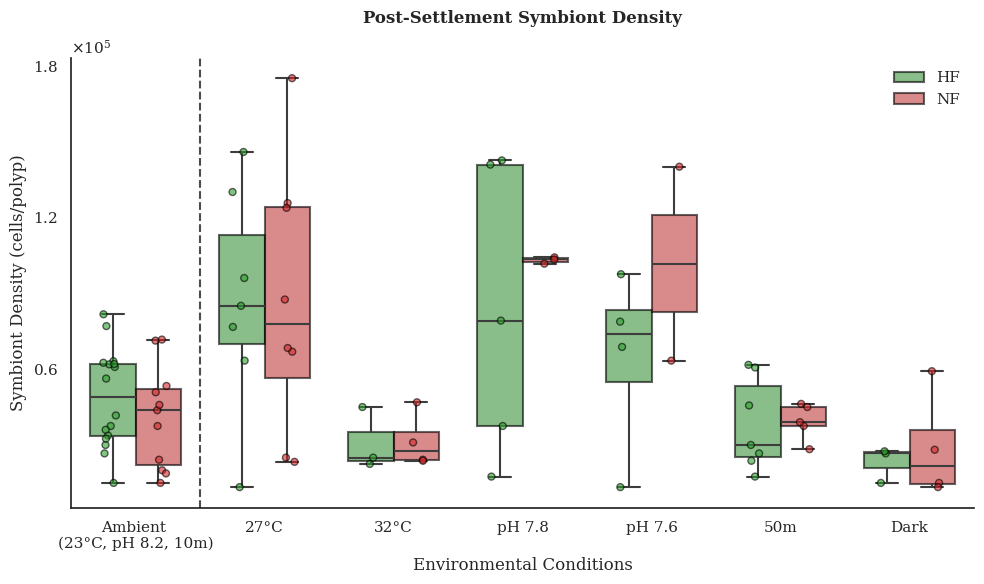

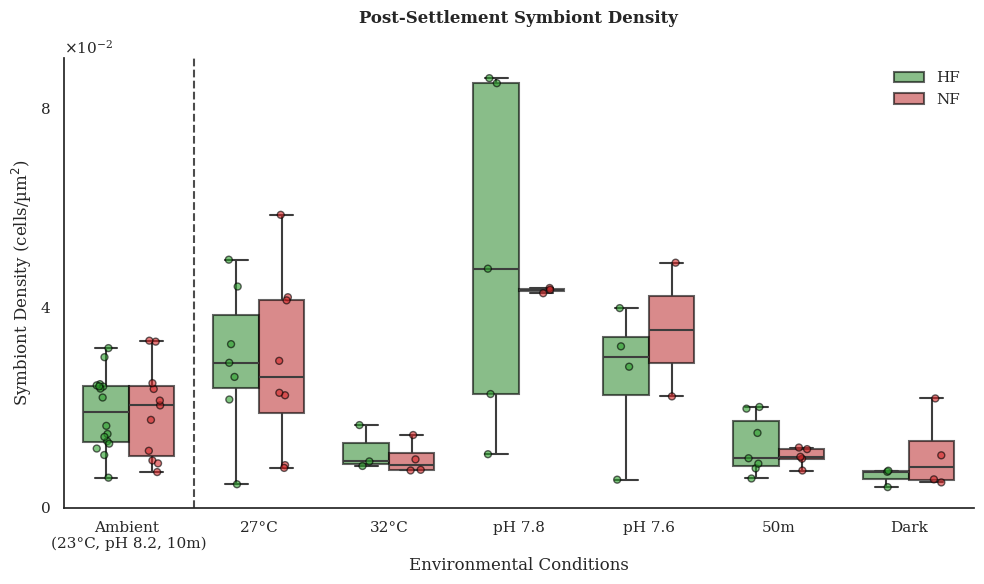

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import PathPatch
import re

# ==========================================
# BLOCK 5: SYMBIONT DENSITY PLOTS
# ==========================================

metrics_plotting_info = [('Conc (Cell/polyp)', r"Symbiont Density (cells/polyp)"), ('Cell_per_area_um2', r"Symbiont Density (cells/µm$^{2}$)")]

for metric, y_label in metrics_plotting_info:
    plot_df = cleaned_master_dfs[metric].copy()
    p_vals = final_p_values.get(metric, {})
    plt.figure(figsize=global_fig_size)
    ax = plt.gca()
    sns.boxplot(data=plot_df, x='Sub_Condition', y=metric, hue='morph', hue_order=['HF', 'NF'], palette=variant_colors, width=0.7, showfliers=False, linewidth=1.5, boxprops={'edgecolor': 'black', 'alpha': 0.6}, order=sub_condition_plot_order, ax=ax)
    sns.stripplot(data=plot_df, x='Sub_Condition', y=metric, hue='morph', hue_order=['HF', 'NF'], palette=variant_colors, size=global_marker_size, jitter=global_jitter, alpha=0.6, dodge=True, zorder=5, edgecolor='black', linewidth=1, order=sub_condition_plot_order, ax=ax, legend=False)
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

    max_y = plot_df[metric].max()
    for idx, sub_label in enumerate(sub_condition_plot_order):
        p_val = p_vals.get(sub_label, 1.0)
        if p_val < 0.05:
            sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
            ax.text(idx, max_y * 1.05, sig_text, ha='center', va='bottom', fontsize=global_asterisk_size, fontweight=global_asterisk_weight)

    ax.set_title("Post-Settlement Symbiont Density", pad=25)
    ax.set_ylabel(y_label)
    ax.set_xlabel("Environmental Conditions")
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=global_y_nbins))

    # Aesthetic Legend refinement
    ax.legend(frameon=False)

    sns.despine()
    plt.tight_layout()
    file_path = f"{re.sub(r'[^a-zA-Z0-9]', '_', metric)}.png"
    plt.savefig(file_path, dpi=600)
    plt.show()

# Protein


## Block 1: Data Upload & Cleaning
Loads both CSV files and standardizes the column names. It corrects the "Treratment" typo in your protein file and ensures the light depths are formatted as clean strings so they can be matched. it also load

In [34]:
# Load the datasets
df_prot = pd.read_csv('ProteinSumUp.csv')

# Clean columns in Protein dataset
df_prot.columns = df_prot.columns.str.strip()
if 'Treratment' in df_prot.columns:
    df_prot = df_prot.rename(columns={'Treratment': 'Treatment'})
df_prot['Treatment'] = df_prot['Treatment'].astype(str).str.strip()
df_prot['morph'] = df_prot['morph'].astype(str).str.strip()

# --- FIX NAMING MISMATCHES ---
# Standardize names and combine 'control' into 'Ambient'
name_fixes = {
    'control': 'Ambient',
    '27c': '27°C',
    '32c': '32°C',
    '7.8': 'pH 7.8',
    '7.6': 'pH 7.6',
    '8.2': 'Ambient',
    'DARK': 'Dark'
}
df_prot['Treatment'] = df_prot['Treatment'].replace(name_fixes)

#Loading Spat Area per Trearment
area_factors_per_morph_treatment = {
    ('HF', 'Ambient \n(23°C, pH 8.2, 10m)'): 2.566,
    ('NF', 'Ambient \n(23°C, pH 8.2, 10m)'): 2.151,
    ('HF', '27°C'): 2.943,
    ('NF', '27°C'): 2.989,
    ('HF', '32°C'): 2.745,
    ('NF', '32°C'): 3.255,
    ('HF', 'pH 7.8'): 1.658,
    ('NF', 'pH 7.8'): 2.374,
    ('HF', 'pH 7.6'): 2.447,
    ('NF', 'pH 7.6'): 2.860,
    ('HF', '50m'): 3.079,
    ('NF', '50m'): 3.889,
    ('HF', 'Dark'): 3.795,
    ('NF', 'Dark'): 2.722,
}


# Filter only HF and NF morphs
df_prot = df_prot[df_prot['morph'].isin(['HF', 'NF'])]

print(f"✅ Block 2 Updated: 'control' combined with 'Ambient'. Total protein records: {len(df_prot)}.")

✅ Block 2 Updated: 'control' combined with 'Ambient'. Total protein records: 84.


## Block 3: Map Areas and Calculate Protein Density
Looks at every row in  protein file, calculates the true protein density (ug/mm2).

In [40]:
def assign_area(row):
    # We need to match the key format: (morph, treatment)
    # The area_factors_per_morph_treatment dictionary uses long 'Ambient' names
    treat = row['Treatment']
    morph = row['morph']

    if treat == 'Ambient':
        lookup_treat = 'Ambient \n(23°C, pH 8.2, 10m)'
    else:
        lookup_treat = treat

    # Retrieve from the global dictionary established in previous blocks
    return area_factors_per_morph_treatment.get((morph, lookup_treat), np.nan)

# 1. Create the Dynamic_Area column by applying the function
df_prot['Dynamic_Area_mm2'] = df_prot.apply(assign_area, axis=1)

# 2. Map areas and calculate density (ug per mm2)
# Formula: [Total ug/ml] / [Area mm2]
df_prot['prot_ug_mm2_calculated'] = df_prot['con per spat ug/ml'] / df_prot['Dynamic_Area_mm2']

# Prepare dataset for analysis - Drop rows without area mapping or density data
df_clean = df_prot.dropna(subset=['prot_ug_mm2_calculated', 'Treatment', 'morph']).copy()

print(f"✅ Block 3 Updated: Areas mapped using global dictionary and density calculated.")
print(f"Dataset contains {len(df_clean)} valid records.")

✅ Block 4 Updated: Areas mapped using global dictionary and density calculated.
Dataset contains 84 valid records.


## Block 4: Automated Statistical Analysis (Protein)
This block determines if the protein density significantly differs between phenotypes. It automatically selects between Parametric (T-test) and Non-Parametric (Mann-Whitney U) methods based on the data distribution.

In [41]:
print("--- BLOCK 4: UPDATED PROTEIN STATISTICAL ANALYSIS ---")

prot_stats_results = []

for treat in df_clean['Treatment'].unique():
    subset = df_clean[df_clean['Treatment'] == treat]
    hf_data = subset[subset['morph'] == 'HF']['prot_ug_mm2_calculated']
    nf_data = subset[subset['morph'] == 'NF']['prot_ug_mm2_calculated']

    # Normality Check
    is_normal = True
    for data in [hf_data, nf_data]:
        if len(data) >= 3:
            _, p = stats.shapiro(data)
            if p <= 0.05: is_normal = False
        else:
            is_normal = False

    # Statistical Test
    if len(hf_data) >= 2 and len(nf_data) >= 2:
        if is_normal:
            stat, p_val = stats.ttest_ind(hf_data, nf_data)
            test_name = "T-test"
        else:
            stat, p_val = stats.mannwhitneyu(hf_data, nf_data)
            test_name = "Mann-Whitney"
    else:
        p_val, test_name = np.nan, "Low N"

    prot_stats_results.append({
        'Condition': treat,
        'HF_Mean': hf_data.mean(),
        'NF_Mean': nf_data.mean(),
        'p_value': p_val,
        'Test': test_name,
        'Significant': p_val < 0.05 if not np.isnan(p_val) else False
    })

prot_results_df = pd.DataFrame(prot_stats_results)
print(prot_results_df[['Condition', 'HF_Mean', 'NF_Mean', 'p_value', 'Significant']].to_string(index=False))

--- BLOCK 5: UPDATED PROTEIN STATISTICAL ANALYSIS ---
Condition   HF_Mean   NF_Mean  p_value  Significant
  Ambient  7.266987 16.466480 0.024041         True
     27°C  8.236433  5.754461 0.177347        False
     32°C 10.825353  6.405782 0.397962        False
      50m 13.973149 13.446115 0.926049        False
     Dark 11.275432 10.178797 0.885714        False
   pH 7.8  9.368134  9.781141 0.879790        False
   pH 7.6  9.015130  8.648011 0.800000        False


## Block 5: High-Impact Visualization (Protein)
This plot visualizes the protein density across all treatments. It uses boxplots for medians and IQRs, overlays raw data points to show variance, and automatically adds significance asterisks based on the results from Block 5.

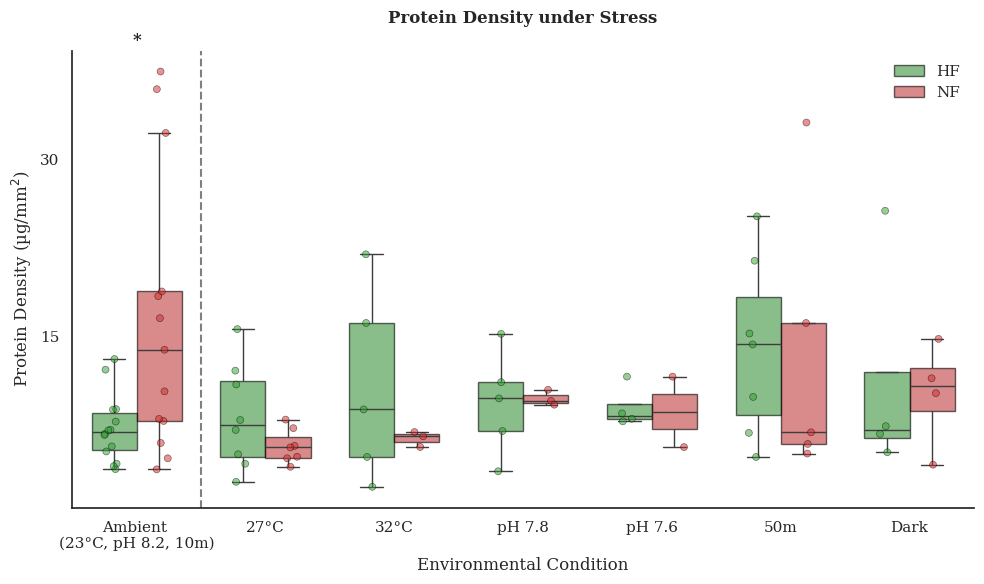

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ==========================================
# BLOCK 5: HIGH-IMPACT VISUALIZATION (PROTEIN)
# ==========================================

df_plot = df_clean.copy()
df_plot['Treatment'] = df_plot['Treatment'].replace('Ambient', 'Ambient \n(23°C, pH 8.2, 10m)')
fig, ax = plt.subplots(figsize=global_fig_size)

sns.boxplot(data=df_plot, x='Treatment', y='prot_ug_mm2_calculated', hue='morph', hue_order=['HF', 'NF'], order=sub_condition_plot_order, palette=variant_colors, width=0.7, boxprops=dict(alpha=global_alpha, edgecolor='black'), showfliers=False, ax=ax)
sns.stripplot(data=df_plot, x='Treatment', y='prot_ug_mm2_calculated', hue='morph', hue_order=['HF', 'NF'], order=sub_condition_plot_order, palette=variant_colors, dodge=True, size=global_marker_size, alpha=0.5, jitter=global_jitter, edgecolor='black', linewidth=0.5, ax=ax, legend=False)

# Updated Significance Logic: Tiered system
if 'prot_results_df' in globals():
    for _, row in prot_results_df.iterrows():
        p_val = row['p_value']
        if p_val < 0.05:
            sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
            treat_label = row['Condition']
            plot_label = 'Ambient \n(23°C, pH 8.2, 10m)' if treat_label == 'Ambient' else treat_label
            if plot_label in sub_condition_plot_order:
                x_idx = sub_condition_plot_order.index(plot_label)
                max_val = df_plot[df_plot['Treatment'] == plot_label]['prot_ug_mm2_calculated'].max()
                ax.text(x_idx, max_val * 1.05, sig_text, ha='center', va='bottom', fontsize=global_asterisk_size, fontweight=global_asterisk_weight)

ax.set_title("Protein Density under Stress", fontweight='bold')
ax.set_xlabel("Environmental Condition")
ax.set_ylabel(r"Protein Density (µg/mm$^{2}$)")
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5)
if 'global_y_nbins' in globals(): ax.yaxis.set_major_locator(plt.MaxNLocator(global_y_nbins))

# Aesthetic Legend refinement
ax.legend(frameon=False)

sns.despine()
plt.tight_layout()
plt.savefig("Protein_Density_Poster_Plot.png", dpi=600, bbox_inches='tight')
plt.show()

# Combine Panel

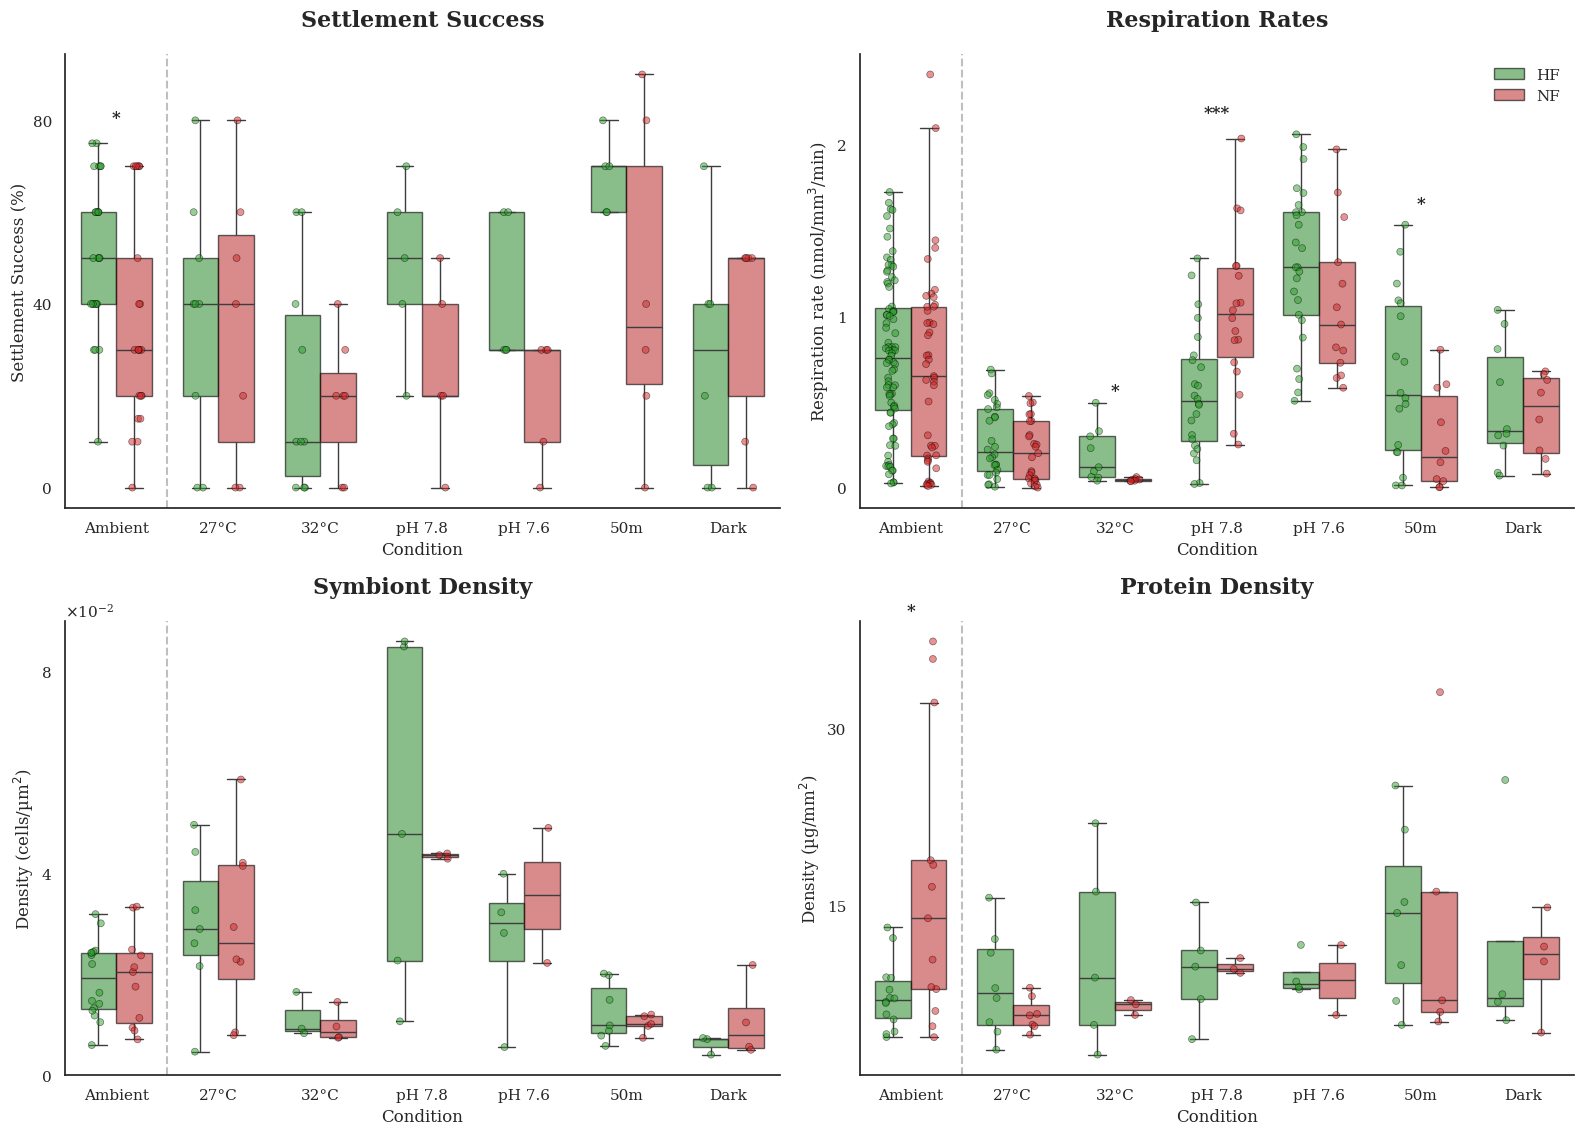

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# --- COMPOSITE FIGURE SETUP ---
plt.rcParams["font.family"] = "Serif"
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

simplified_order = ['Ambient', '27°C', '32°C', 'pH 7.8', 'pH 7.6', '50m', 'Dark']
specific_hue_order = ['HF', 'NF']
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

# Helper to add significance with tiered asterisks
def add_sig_composite(ax, df, results, order, metric_col, treat_col='Condition'):
    for _, row in results.iterrows():
        p_val = row['p_value']
        if p_val < 0.05:
            sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
            treat = row[treat_col]
            plot_label = 'Ambient' if treat == 'Ambient' else treat
            if plot_label in order:
                idx = order.index(plot_label)
                mask = (df['Treatment_Short'] == plot_label) if 'Treatment_Short' in df.columns else (df['Treatment'] == plot_label)
                y_pos = df[mask][metric_col].max()
                ax.text(idx, y_pos * 1.05, sig_text, ha='center', va='bottom', fontsize=global_asterisk_size, fontweight=global_asterisk_weight)

# PANEL A
ax0 = axes[0]
master_df_clean['Treatment_Short'] = master_df_clean['Treatment'].replace('Ambient \n(23°C, pH 8.2, 10m)', 'Ambient')
sns.boxplot(data=master_df_clean, x='Treatment_Short', y='settlement', hue='morph', hue_order=specific_hue_order, order=simplified_order, palette=variant_colors, ax=ax0, width=0.7, boxprops=dict(alpha=global_alpha, edgecolor='black'), showfliers=False)
sns.stripplot(data=master_df_clean, x='Treatment_Short', y='settlement', hue='morph', hue_order=specific_hue_order, order=simplified_order, palette=variant_colors, ax=ax0, dodge=True, size=global_marker_size, alpha=0.5, jitter=global_jitter, edgecolor='black', linewidth=0.5, legend=False)
add_sig_composite(ax0, master_df_clean, results_df, simplified_order, 'settlement')
ax0.set_title("Settlement Success", fontsize=16, fontweight='bold')
ax0.set_ylabel("Settlement Success (%)")

# PANEL B
ax1 = axes[1]
respiration_clean['Treatment_Short'] = respiration_clean['Treatment'].replace('Ambient \n(23°C, pH 8.2, 10m)', 'Ambient')
sns.boxplot(data=respiration_clean, x='Treatment_Short', y='oxy_rate', hue='morph', hue_order=specific_hue_order, order=simplified_order, palette=variant_colors, ax=ax1, width=0.7, boxprops=dict(alpha=global_alpha, edgecolor='black'), showfliers=False)
sns.stripplot(data=respiration_clean, x='Treatment_Short', y='oxy_rate', hue='morph', hue_order=specific_hue_order, order=simplified_order, palette=variant_colors, ax=ax1, dodge=True, size=global_marker_size, alpha=0.5, jitter=global_jitter, edgecolor='black', linewidth=0.5, legend=False)
add_sig_composite(ax1, respiration_clean, oxy_results_df, simplified_order, 'oxy_rate')
ax1.set_title("Respiration Rates", fontsize=16, fontweight='bold')
ax1.set_ylabel(r"Respiration rate (nmol/mm$^3$/min)")

# PANEL C (Symbionts)
ax2 = axes[2]
symb_plot_df = cleaned_master_dfs['Cell_per_area_um2'].copy()
symb_plot_df['Sub_Condition_Short'] = symb_plot_df['Sub_Condition'].replace('Ambient \n(23°C, pH 8.2, 10m)', 'Ambient')
sns.boxplot(data=symb_plot_df, x='Sub_Condition_Short', y='Cell_per_area_um2', hue='morph', hue_order=specific_hue_order, order=simplified_order, palette=variant_colors, ax=ax2, width=0.7, boxprops=dict(alpha=global_alpha, edgecolor='black'), showfliers=False)
sns.stripplot(data=symb_plot_df, x='Sub_Condition_Short', y='Cell_per_area_um2', hue='morph', hue_order=specific_hue_order, order=simplified_order, palette=variant_colors, ax=ax2, dodge=True, size=global_marker_size, alpha=0.5, jitter=global_jitter, edgecolor='black', linewidth=0.5, legend=False)
for idx, sub_label in enumerate(simplified_order):
    lookup = 'Ambient \n(23°C, pH 8.2, 10m)' if sub_label == 'Ambient' else sub_label
    p_val = final_p_values['Cell_per_area_um2'].get(lookup, 1.0)
    if p_val < 0.05:
        sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
        y_pos = symb_plot_df[symb_plot_df['Sub_Condition_Short'] == sub_label]['Cell_per_area_um2'].max()
        ax2.text(idx, y_pos * 1.05, sig_text, ha='center', va='bottom', fontsize=global_asterisk_size, fontweight=global_asterisk_weight)
ax2.set_title("Symbiont Density", fontsize=16, fontweight='bold')
ax2.set_ylabel(r"Density (cells/µm$^{2}$)")
ax2.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

# PANEL D (Protein)
ax3 = axes[3]
df_plot['Treatment_Short'] = df_plot['Treatment'].replace('Ambient \n(23°C, pH 8.2, 10m)', 'Ambient')
sns.boxplot(data=df_plot, x='Treatment_Short', y='prot_ug_mm2_calculated', hue='morph', hue_order=specific_hue_order, order=simplified_order, palette=variant_colors, ax=ax3, width=0.7, boxprops=dict(alpha=global_alpha, edgecolor='black'), showfliers=False)
sns.stripplot(data=df_plot, x='Treatment_Short', y='prot_ug_mm2_calculated', hue='morph', hue_order=specific_hue_order, order=simplified_order, palette=variant_colors, ax=ax3, dodge=True, size=global_marker_size, alpha=0.5, jitter=global_jitter, edgecolor='black', linewidth=0.5, legend=False)
add_sig_composite(ax3, df_plot, prot_results_df, simplified_order, 'prot_ug_mm2_calculated')
ax3.set_title("Protein Density", fontsize=16, fontweight='bold')
ax3.set_ylabel(r"Density (µg/mm$^{2}$)")

for i, ax in enumerate(axes):
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel("Condition")
    # Only keep legend for Panel B, but remove frame
    if i == 1:
        leg = ax.legend(loc='upper right', frameon=False)
    else:
        if ax.get_legend(): ax.get_legend().remove()
    if 'global_y_nbins' in globals(): ax.yaxis.set_major_locator(plt.MaxNLocator(global_y_nbins))

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("Spat_Physiology_Panel.png", dpi=600, bbox_inches='tight')
plt.show()

# Combine Statistical Output

In [60]:
import pandas as pd

# --- AGGREGATE STATISTICAL SUMMARIES ---

# 1. Panel A: Settlement
summary_a = results_df[['Condition', 'HF_Mean', 'NF_Mean', 'p_value', 'Test_Used']].copy()
summary_a['Metric'] = 'Settlement (%)'
summary_a = summary_a.rename(columns={'HF_Mean': 'HF_Value', 'NF_Mean': 'NF_Value'})

# 2. Panel B: Respiration
summary_b = oxy_results_df[['Condition', 'HF_Mean_Rate', 'NF_Mean_Rate', 'p_value', 'Test_Used']].copy()
summary_b['Metric'] = 'Respiration (nmol/mm3/min)'
summary_b = summary_b.rename(columns={'HF_Mean_Rate': 'HF_Value', 'NF_Mean_Rate': 'NF_Value'})

# 3. Panel C: Symbionts
symb_data = []
for cond in sub_condition_plot_order:
    cond_short = cond.replace('Ambient \n(23°C, pH 8.2, 10m)', 'Ambient')
    p_val = final_p_values['Cell_per_area_um2'].get(cond, 1.0)
    subset = cleaned_master_dfs['Cell_per_area_um2'][cleaned_master_dfs['Cell_per_area_um2']['Sub_Condition'] == cond]
    hf_m = subset[subset['morph'] == 'HF']['Cell_per_area_um2'].mean()
    nf_m = subset[subset['morph'] == 'NF']['Cell_per_area_um2'].mean()
    symb_data.append({
        'Condition': cond_short,
        'Metric': 'Symbiont Density (cells/um2)',
        'HF_Value': hf_m,
        'NF_Value': nf_m,
        'p_value': p_val,
        'Test_Used': 'Auto (T-test/MWU)'
    })
summary_c = pd.DataFrame(symb_data)

# 4. Panel D: Protein - Fixed column names from prot_results_df
summary_d = prot_results_df[['Condition', 'HF_Mean', 'NF_Mean', 'p_value', 'Test']].copy()
summary_d['Metric'] = 'Protein Density (ug/mm2)'
summary_d = summary_d.rename(columns={'HF_Mean': 'HF_Value', 'NF_Mean': 'NF_Value', 'Test': 'Test_Used'})

# --- COMBINE ALL ---
master_stats_summary = pd.concat([summary_a, summary_b, summary_c, summary_d], ignore_index=True)
master_stats_summary['Condition'] = master_stats_summary['Condition'].str.replace('Ambient \n(23°C, pH 8.2, 10m)', 'Ambient')
master_stats_summary['Sig'] = master_stats_summary['p_value'].apply(lambda x: '*' if x < 0.05 else ('**' if x < 0.01 else ('***' if x < 0.001 else 'ns')))
master_stats_summary = master_stats_summary[['Metric', 'Condition', 'HF_Value', 'NF_Value', 'p_value', 'Sig', 'Test_Used']]

print("=== CONSOLIDATED STATISTICAL OUTPUT (PANELS A-D) ===")
pd.options.display.float_format = '{:,.4f}'.format
display(master_stats_summary.sort_values(['Metric', 'Condition']))
master_stats_summary.to_csv("Master_Consolidated_Stats.csv", index=False)

=== CONSOLIDATED STATISTICAL OUTPUT (PANELS A-D) ===


,Metric,Condition,HF_Value,NF_Value,p_value,Sig,Test_Used
22,Protein Density (ug/mm2),27°C,8.2364,5.7545,0.1773,ns,T-test
23,Protein Density (ug/mm2),32°C,10.8254,6.4058,0.3980,ns,T-test
24,Protein Density (ug/mm2),50m,13.9731,13.4461,0.9260,ns,T-test
21,Protein Density (ug/mm2),Ambient,7.2670,16.4665,0.0240,*,Mann-Whitney
25,Protein Density (ug/mm2),Dark,11.2754,10.1788,0.8857,ns,Mann-Whitney
27,Protein Density (ug/mm2),pH 7.6,9.0151,8.6480,0.8000,ns,Mann-Whitney
26,Protein Density (ug/mm2),pH 7.8,9.3681,9.7811,0.8798,ns,T-test
10,Respiration (nmol/mm3/min),27°C,0.2752,0.2159,0.2891,ns,Mann-Whitney U
11,Respiration (nmol/mm3/min),32°C,0.1927,0.0467,0.0283,*,Independent T-test
12,Respiration (nmol/mm3/min),50m,0.6417,0.2834,0.0420,*,Independent T-test


# Libraries Versions

In [61]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import scipy
import sys

# Create a dictionary to hold version info
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Matplotlib": matplotlib.__version__,
    "Seaborn": sns.__version__,
    "SciPy": scipy.__version__
}

print("=== LIBRARY VERSIONS FOR PEER REVIEW ===")
for lib, ver in versions.items():
    print(f"{lib}: {ver}")

=== LIBRARY VERSIONS FOR PEER REVIEW ===
Python: 3.12.13
Pandas: 2.2.2
NumPy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2
SciPy: 1.16.3
